In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [59]:
claims = pd.read_csv('cleaned_claims.csv')
staging = pd.read_csv('cleaned_staging.csv')

In [60]:
print("Claims members:", claims['member_number'].nunique())
print("Staging members:", staging['member_number'].nunique())

Claims members: 3657
Staging members: 3392


In [61]:
claims_members = set(claims['member_number'])
staging_members = set(staging['member_number'])

print("Overlap:", len(claims_members & staging_members))
print("Claims only:", len(claims_members - staging_members))
print("Staging only:", len(staging_members - claims_members))

Overlap: 3392
Claims only: 265
Staging only: 0


In [62]:
# inner join
claims_merged = claims.merge(
    staging,
    on='member_number',
    how='inner'
)

In [63]:
print("Merged shape:", claims_merged.shape)
print("Merged unique members:", claims_merged['member_number'].nunique())

Merged shape: (2310037, 29)
Merged unique members: 3392


In [64]:
# where staging occurs relative to day 0
claims_merged['days_from_stage'] = (
    claims_merged['days_since_earliest_dt'] -
    claims_merged['most_recent_stage_date']
)

In [65]:
staging['most_recent_stage_date'].describe()

count    3392.000000
mean      121.734965
std       644.505954
min     -3089.000000
25%        10.000000
50%        45.000000
75%       125.000000
max      3613.000000
Name: most_recent_stage_date, dtype: float64

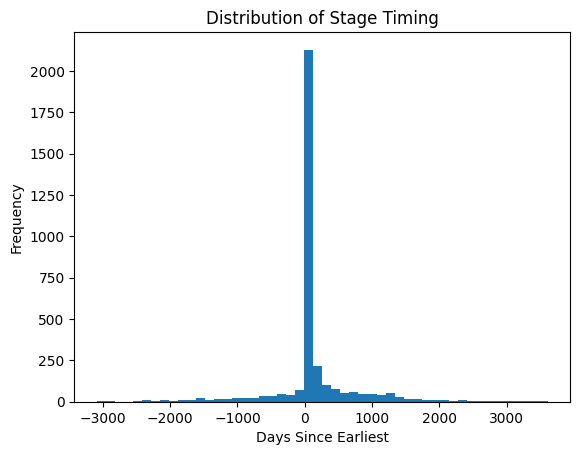

In [66]:
plt.hist(staging['most_recent_stage_date'], bins=50)
plt.title('Distribution of Stage Timing')
plt.xlabel('Days Since Earliest')
plt.ylabel('Frequency')
plt.show()

In [67]:
staging['most_recent_stage_date'].quantile([0.25, 0.5, 0.75])

0.25     10.0
0.50     45.0
0.75    125.0
Name: most_recent_stage_date, dtype: float64

In [68]:
staging['final_stage_simple'].value_counts()

final_stage_simple
I      1770
II      633
III     596
IV      393
Name: count, dtype: int64

In [69]:
stage_daily_cost = (
    claims_merged
    .groupby(['days_since_earliest_dt', 'final_stage_simple'])['c_allowed']
    .mean()
    .reset_index()
)

stage_daily_cost

,days_since_earliest_dt,final_stage_simple,c_allowed
0,-366,I,115.794936
1,-366,II,94.114158
2,-366,III,38.475358
3,-366,IV,80.484616
4,-365,I,72.802923
...,...,...,...
15971,3801,I,342.492584
15972,3806,I,3.960718
15973,3809,I,96.851826
15974,3813,I,136.434479


In [70]:
pivot = stage_daily_cost.pivot(
    index='days_since_earliest_dt',
    columns='final_stage_simple',
    values='c_allowed'
)

In [71]:
pivot = pivot[pivot.index <= 2000]

In [72]:
pivot_rolling = pivot.rolling(window=30, min_periods=1).mean()

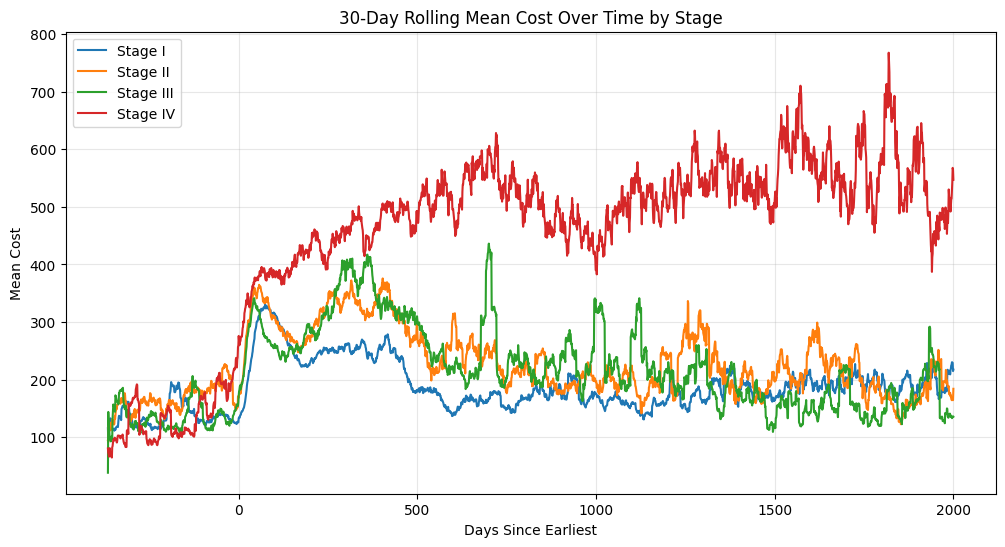

In [73]:
plt.figure(figsize=(12, 6))

for stage in pivot_rolling.columns:
    plt.plot(
        pivot_rolling.index,
        pivot_rolling[stage],
        label=f"Stage {stage}"
    )

plt.title("30-Day Rolling Mean Cost Over Time by Stage")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

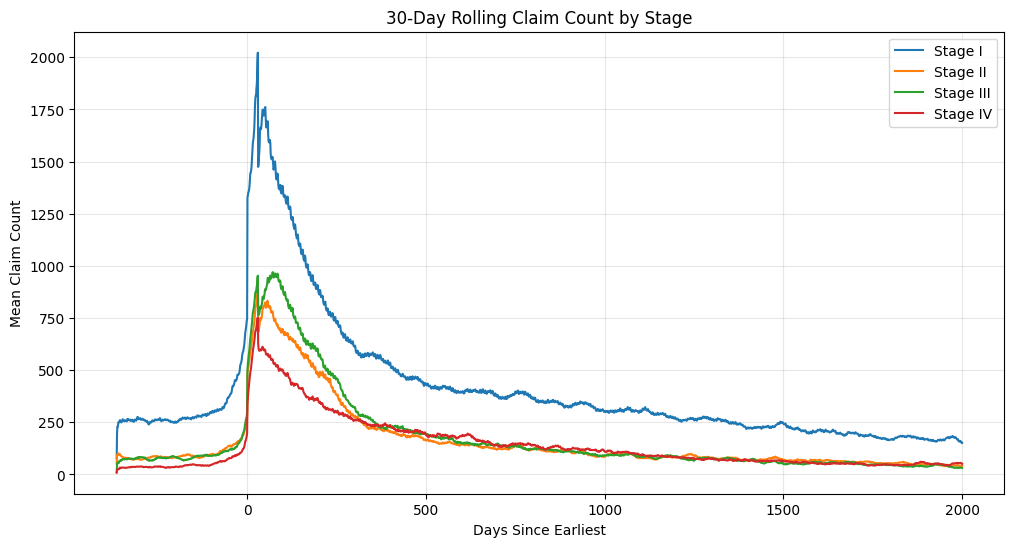

In [74]:
stage_daily_claims = (
    claims_merged
    .groupby(['days_since_earliest_dt', 'final_stage_simple'])
    .size()
    .reset_index(name='claim_count')
)

pivot_claims = stage_daily_claims.pivot(
    index='days_since_earliest_dt',
    columns='final_stage_simple',
    values='claim_count'
)

pivot_claims = pivot_claims[pivot_claims.index <= 2000]

pivot_claims_rolling = pivot_claims.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12, 6))

for stage in pivot_claims_rolling.columns:
    plt.plot(
        pivot_claims_rolling.index,
        pivot_claims_rolling[stage],
        label=f"Stage {stage}"
    )

plt.title("30-Day Rolling Claim Count by Stage")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Claim Count")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [75]:
# Filter to Stage IV patients
stage_iv = claims_merged[
    claims_merged['final_stage_simple'] == 'IV'
]

# Identify unique Stage IV patients
stage_iv_patients = (
    stage_iv[['member_number', 'most_recent_stage_date']]
    .drop_duplicates()
)

# Define cohorts
early_patients = stage_iv_patients[
    stage_iv_patients['most_recent_stage_date'] < 30
]['member_number']

late_patients = stage_iv_patients[
    stage_iv_patients['most_recent_stage_date'] > 180
]['member_number']

print("Early Stage IV patients:", early_patients.nunique())
print("Late Stage IV patients:", late_patients.nunique())

Early Stage IV patients: 182
Late Stage IV patients: 138


In [76]:
early_claims = stage_iv[
    stage_iv['member_number'].isin(early_patients)
]

late_claims = stage_iv[
    stage_iv['member_number'].isin(late_patients)
]

In [77]:
early_daily = (
    early_claims
    .groupby('days_since_earliest_dt')
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

early_daily['cost_per_patient'] = (
    early_daily['total_cost'] /
    early_daily['unique_members']
)

In [78]:
late_daily = (
    late_claims
    .groupby('days_since_earliest_dt')
    .agg(
        total_cost=('c_allowed', 'sum'),
        unique_members=('member_number', 'nunique')
    )
    .reset_index()
)

late_daily['cost_per_patient'] = (
    late_daily['total_cost'] /
    late_daily['unique_members']
)

In [79]:
max_day = 2000

early_daily = early_daily[early_daily['days_since_earliest_dt'] <= max_day]
late_daily = late_daily[late_daily['days_since_earliest_dt'] <= max_day]

In [80]:
early_daily['rolling_cost'] = (
    early_daily['cost_per_patient']
    .rolling(30, min_periods=1)
    .mean()
)

late_daily['rolling_cost'] = (
    late_daily['cost_per_patient']
    .rolling(30, min_periods=1)
    .mean()
)

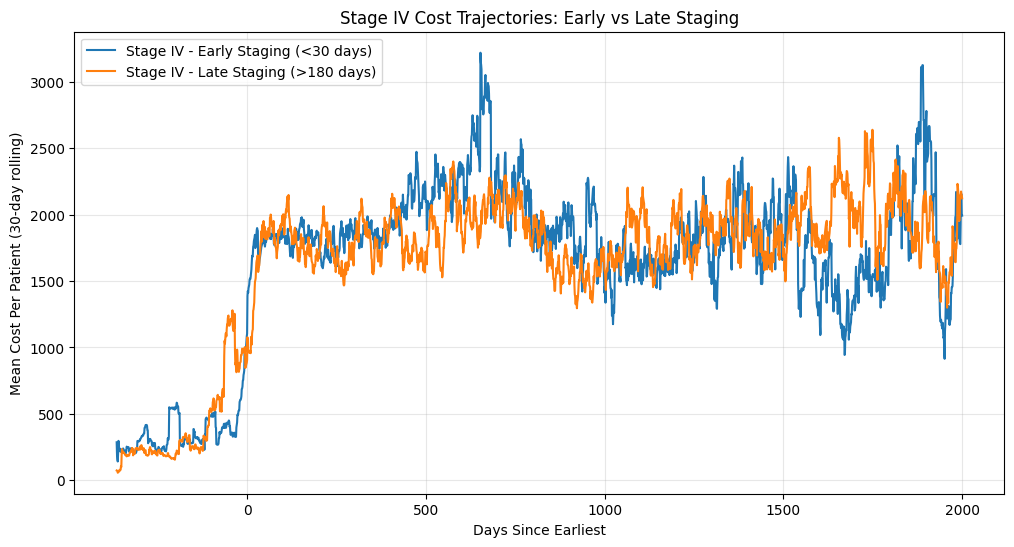

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    early_daily['days_since_earliest_dt'],
    early_daily['rolling_cost'],
    label='Stage IV - Early Staging (<30 days)'
)

plt.plot(
    late_daily['days_since_earliest_dt'],
    late_daily['rolling_cost'],
    label='Stage IV - Late Staging (>180 days)'
)

plt.title("Stage IV Cost Trajectories: Early vs Late Staging")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost Per Patient (30-day rolling)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [82]:
claims_merged['phase'] = np.select(
    [
        claims_merged['days_since_earliest_dt'] <= 180,
        claims_merged['days_since_earliest_dt'] <= 1000
    ],
    ['initial', 'continuing'],
    default='late'
)

# Aggregate to patient level
patient_summary = (
    claims_merged
    .groupby('member_number')
    .agg(
        cancer_type=('cancer_type', 'first'),
        stage=('final_stage_simple', 'first'),
        time_to_stage=('most_recent_stage_date', 'first'),
        followup_time=('days_since_earliest_dt', 'max'),
        total_cost=('c_allowed', 'sum')
    )
    .reset_index()
)

In [83]:
phase_costs = (
    claims_merged
    .groupby(['member_number', 'phase'])['c_allowed']
    .sum()
    .unstack(fill_value=0)
    .reset_index()
)

patient_summary = patient_summary.merge(
    phase_costs,
    on='member_number',
    how='left'
)

In [84]:
duration_summary = (
    patient_summary
    .groupby(['cancer_type', 'stage'])
    .agg(
        mean_time_to_stage=('time_to_stage', 'mean'),
        median_time_to_stage=('time_to_stage', 'median'),
        mean_followup=('followup_time', 'mean'),
        count=('member_number', 'count')
    )
    .reset_index()
)

duration_summary

,cancer_type,stage,mean_time_to_stage,median_time_to_stage,mean_followup,count
0,breast,I,116.771893,55.0,1522.992232,1416
1,breast,II,153.826667,52.0,1552.709333,375
2,breast,III,288.392857,58.5,1605.314286,140
3,breast,IV,518.263636,197.0,1530.109091,110
4,colorectal,I,123.802198,53.0,1560.538462,91
5,colorectal,II,-2.695652,36.0,1172.668478,184
6,colorectal,III,10.767516,28.0,1275.407643,314
7,colorectal,IV,319.912281,55.5,1099.026316,114
8,lung,I,73.171103,6.0,1197.593156,263
9,lung,II,-33.621622,26.0,1053.418919,74


In [85]:
patient_summary['initial_rate'] = (
    patient_summary['initial'] / 180
)

patient_summary['continuing_rate'] = (
    patient_summary['continuing'] / 820  # 1000-180
)

patient_summary['late_rate'] = (
    patient_summary['late'] / 
    np.maximum(patient_summary['followup_time'] - 1000, 1)
)

In [86]:
from sklearn.preprocessing import StandardScaler

features = [
    'time_to_stage',
    'followup_time',
    'initial_rate',
    'continuing_rate',
    'late_rate'
]

X = patient_summary[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

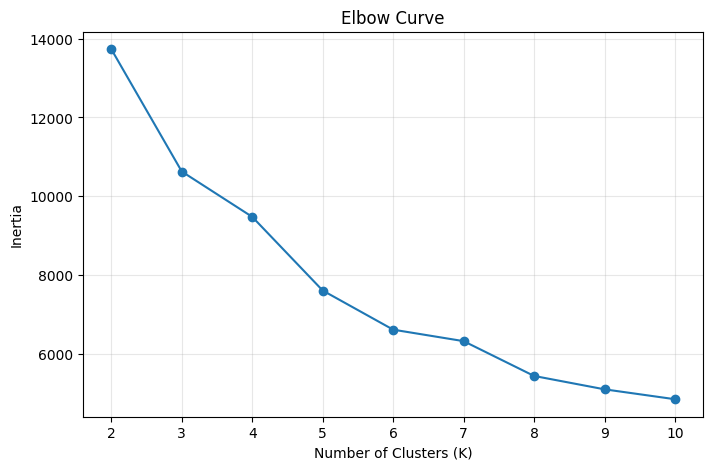

In [87]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Curve")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(alpha=0.3)
plt.show()

In [88]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
patient_summary['cluster'] = kmeans.fit_predict(X_scaled)

In [89]:
cluster_summary = (
    patient_summary
    .groupby('cluster')
    .agg(
        count=('member_number', 'count'),
        mean_time_to_stage=('time_to_stage', 'mean'),
        mean_total_cost=('total_cost', 'mean'),
        mean_initial=('initial_rate', 'mean'),
        mean_continuing=('continuing_rate', 'mean'),
        mean_late=('late_rate', 'mean')
    )
)

cluster_summary

,count,mean_time_to_stage,mean_total_cost,mean_initial,mean_continuing,mean_late
cluster,,,,,,
0,1134,100.954145,154732.911534,294.792924,55.926726,50.137921
1,277,141.018051,776902.188661,1053.801323,478.294213,284.751128
2,295,1523.722034,191431.071360,148.862241,49.981863,79.853725
3,1686,-112.762159,99097.398539,323.932790,48.150515,7.116915


In [90]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

patient_summary['PC1'] = X_pca[:, 0]
patient_summary['PC2'] = X_pca[:, 1]

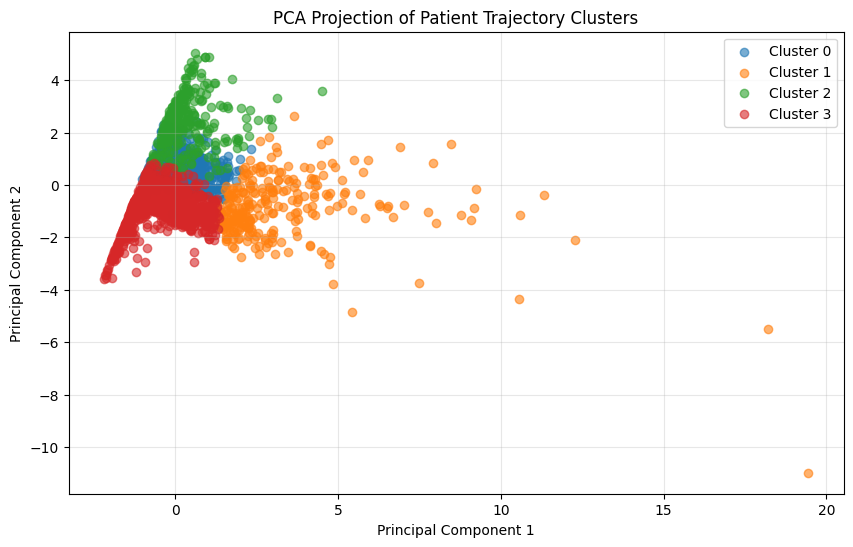

In [91]:
plt.figure(figsize=(10,6))

for cluster_id in sorted(patient_summary['cluster'].unique()):
    subset = patient_summary[patient_summary['cluster'] == cluster_id]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Cluster {cluster_id}',
        alpha=0.6
    )

plt.title("PCA Projection of Patient Trajectory Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

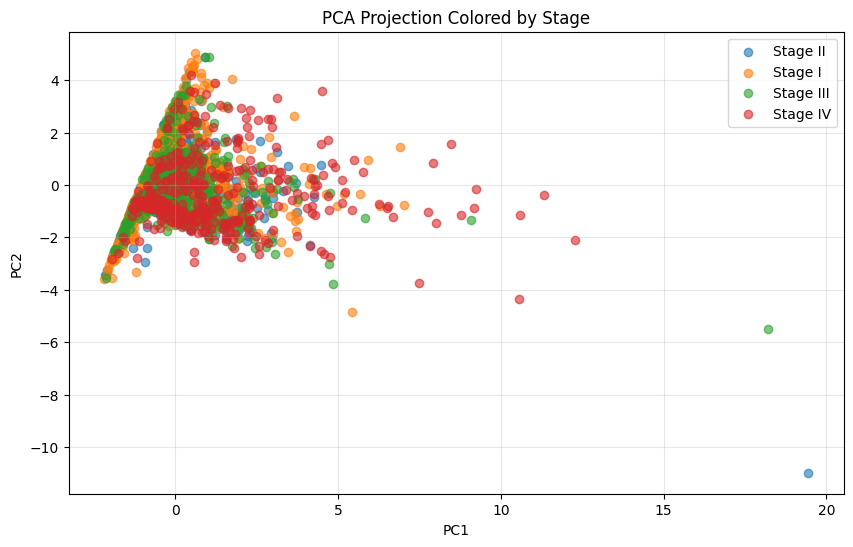

In [92]:
plt.figure(figsize=(10,6))

for stage in patient_summary['stage'].unique():
    subset = patient_summary[patient_summary['stage'] == stage]
    
    plt.scatter(
        subset['PC1'],
        subset['PC2'],
        label=f'Stage {stage}',
        alpha=0.6
    )

plt.title("PCA Projection Colored by Stage")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [93]:
print("Explained variance:", pca.explained_variance_ratio_)

Explained variance: [0.35966977 0.28370733]


In [94]:
from sklearn.metrics import pairwise_distances

distances = pairwise_distances(X_scaled, kmeans.cluster_centers_)
min_distance = distances.min(axis=1)

patient_summary['distance_from_cluster'] = min_distance

In [95]:
threshold = patient_summary['distance_from_cluster'].quantile(0.99)

outliers = patient_summary[
    patient_summary['distance_from_cluster'] > threshold
]

outliers

,member_number,cancer_type,stage,time_to_stage,followup_time,total_cost,continuing,initial,late,initial_rate,continuing_rate,late_rate,cluster,PC1,PC2,distance_from_cluster
165,A182,lung,IV,-6.0,200,4.597808e+05,5.861400e+03,4.539193e+05,0.000000e+00,2521.774167,7.148049,0.000000,1,2.019271,-2.740726,5.227628
328,A354,colorectal,I,5.0,326,9.617151e+05,8.168693e+04,8.800282e+05,0.000000e+00,4889.045333,99.618207,0.000000,1,5.435682,-4.845198,10.258010
377,A406,breast,I,226.0,1410,4.894968e+05,4.887910e+04,2.386371e+04,4.167540e+05,132.576167,59.608657,1016.473070,1,2.944915,1.055254,6.010919
471,A506,breast,IV,346.0,2666,3.780082e+06,1.074333e+06,2.572292e+05,2.448520e+06,1429.051111,1310.161683,1469.700160,1,11.322671,-0.395550,9.568157
497,A532,lung,I,0.0,1071,9.684497e+05,8.199589e+05,7.244423e+04,7.604649e+04,402.467944,999.949939,1071.077324,1,7.022515,-0.773943,6.393030
676,A728,colorectal,III,-659.0,1019,7.213601e+04,4.616004e+04,4.430190e+03,2.154578e+04,24.612167,56.292727,1133.988372,1,2.847770,0.134763,6.901217
677,A729,breast,III,203.0,469,9.312367e+05,2.743526e+05,6.568840e+05,0.000000e+00,3649.355799,334.576374,0.000000,1,4.858477,-3.769401,6.987066
748,A803,colorectal,IV,342.0,1416,1.422139e+06,6.997837e+05,3.393934e+05,3.829617e+05,1885.519056,853.394752,920.581051,1,8.002516,-1.446735,5.292081
900,A965,breast,III,14.0,1187,2.961593e+06,1.979467e+06,7.298412e+05,2.522854e+05,4054.673128,2413.984002,1349.119746,1,18.203345,-5.483619,15.779497
982,B050,colorectal,IV,805.0,1021,1.122526e+06,8.375210e+05,2.593622e+05,2.564285e+04,1440.901023,1021.367098,1221.087908,1,9.185301,-0.866173,7.254344


In [96]:
pd.crosstab(patient_summary['cluster'], patient_summary['stage'])

stage,I,II,III,IV
cluster,,,,
0,710,201,177,46
1,60,57,54,106
2,151,53,40,51
3,849,322,325,190


In [97]:
pd.crosstab(patient_summary['cluster'], patient_summary['cancer_type'])

cancer_type,breast,colorectal,lung
cluster,,,
0,778,218,138
1,142,43,92
2,224,39,32
3,897,403,386


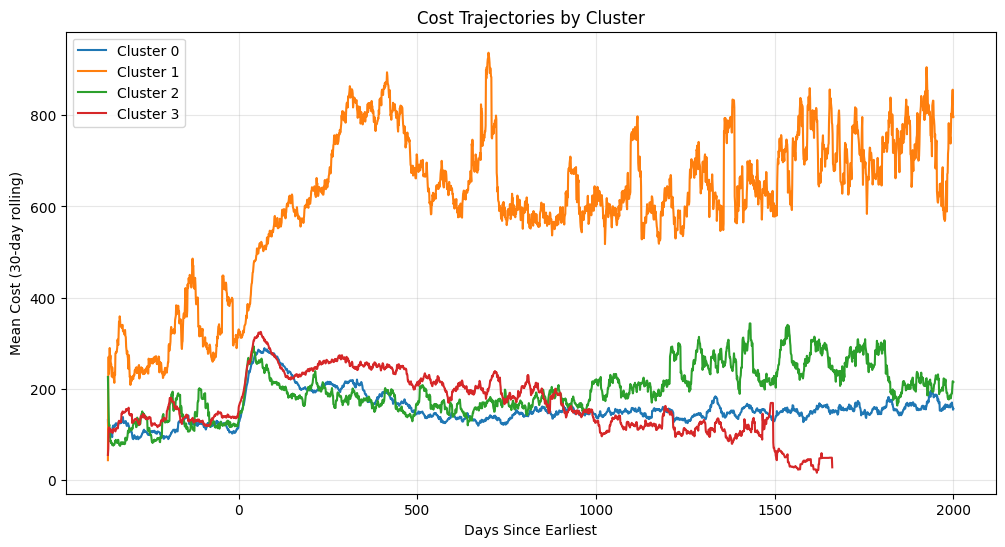

In [98]:
cluster_daily_cost = (
    claims_merged
    .merge(patient_summary[['member_number', 'cluster']],
           on='member_number')
    .groupby(['days_since_earliest_dt', 'cluster'])['c_allowed']
    .mean()
    .reset_index()
)

pivot_cluster = cluster_daily_cost.pivot(
    index='days_since_earliest_dt',
    columns='cluster',
    values='c_allowed'
)

pivot_cluster = pivot_cluster[pivot_cluster.index <= 2000]

pivot_cluster_rolling = pivot_cluster.rolling(30, min_periods=1).mean()

plt.figure(figsize=(12,6))

for c in pivot_cluster_rolling.columns:
    plt.plot(
        pivot_cluster_rolling.index,
        pivot_cluster_rolling[c],
        label=f'Cluster {c}'
    )

plt.title("Cost Trajectories by Cluster")
plt.xlabel("Days Since Earliest")
plt.ylabel("Mean Cost (30-day rolling)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [99]:
patient_summary.groupby('cluster')['followup_time'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,1134.0,2245.873016,571.898745,1030.0,1757.25,2208.0,2683.0,3629.0
1,277.0,1407.169675,774.220793,200.0,840.00,1206.0,1905.0,3617.0
2,295.0,2598.067797,1036.505866,72.0,1703.00,3068.0,3526.5,3819.0
3,1686.0,586.725979,399.616289,0.0,245.25,533.5,915.0,1632.0


In [100]:
cohort = claims_merged[
    (claims_merged['cancer_type'] == 'breast') &
    (claims_merged['final_stage_simple'] == 'II')
].copy()

In [101]:
cohort['member_number'].nunique()

375

In [102]:
def compute_patient_features(df):

    patient_features = []

    for pid, g in df.groupby('member_number'):

        g = g.sort_values('days_since_earliest_dt')

        time_to_stage = g['most_recent_stage_date'].iloc[0]
        followup = g['days_since_earliest_dt'].max()

        initial = g[g['days_since_earliest_dt'] <= 180]['c_allowed'].mean()
        continuing = g[
            (g['days_since_earliest_dt'] > 180) &
            (g['days_since_earliest_dt'] <= 1000)
        ]['c_allowed'].mean()

        late = g[
            g['days_since_earliest_dt'] >= (followup - 180)
        ]['c_allowed'].mean()

        total_cost = g['c_allowed'].sum()

        patient_features.append({
            'member_number': pid,
            'time_to_stage': time_to_stage,
            'followup': followup,
            'mean_initial': initial,
            'mean_continuing': continuing,
            'mean_late': late,
            'total_cost': total_cost
        })

    return pd.DataFrame(patient_features)


patient_matrix = compute_patient_features(cohort)
patient_matrix

,member_number,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
0,A001,203.0,1,156.839041,NaN,187.033826,34347.750000
1,A004,-2843.0,195,56.226560,17.337955,53.973375,1570.130976
2,A026,17.0,625,207.208476,323.433291,136.773802,278864.580000
3,A030,0.0,1406,621.302815,826.205939,37.087769,530468.057012
4,A051,255.0,1045,252.703045,71.623028,27.573604,52941.183678
...,...,...,...,...,...,...,...
370,D604,98.0,625,215.459027,664.362494,726.422722,412242.077780
371,D629,7.0,185,496.011845,88.395973,564.925906,197093.494343
372,D634,-1668.0,357,67.286697,92.943905,92.943905,9835.066083
373,D645,16.0,12,111.913668,NaN,82.340181,7722.043083


In [103]:
patient_matrix = patient_matrix.fillna(0)

In [104]:
from sklearn.preprocessing import StandardScaler

features = [
    'time_to_stage',
    'followup',
    'mean_initial',
    'mean_continuing',
    'mean_late',
    'total_cost'
]

scaler = StandardScaler()
X = scaler.fit_transform(patient_matrix[features])

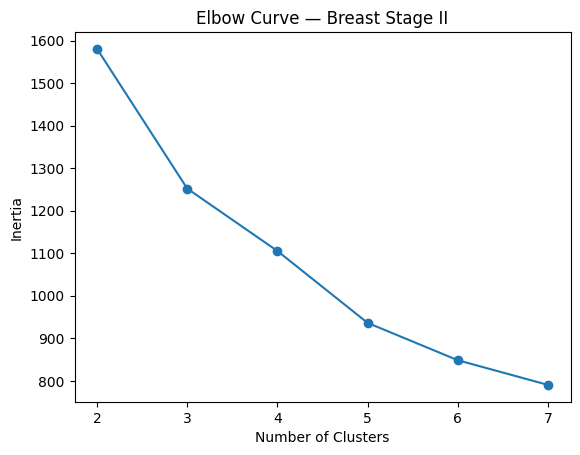

In [105]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.title("Elbow Curve — Breast Stage II")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [106]:
kmeans = KMeans(n_clusters=3, random_state=42)
patient_matrix['cluster'] = kmeans.fit_predict(X)

In [107]:
patient_matrix.groupby('cluster')[features].mean()

,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
cluster,,,,,,
0,-102.524324,770.513514,193.219446,128.538080,167.983358,95004.575060
1,133.468750,1275.843750,476.611841,662.855065,571.157738,512423.530981
2,540.555556,2841.801587,188.175502,149.074471,156.681559,165455.157903


In [108]:
cohort = cohort.merge(
    patient_matrix[['member_number', 'cluster']],
    on='member_number',
    how='left'
)

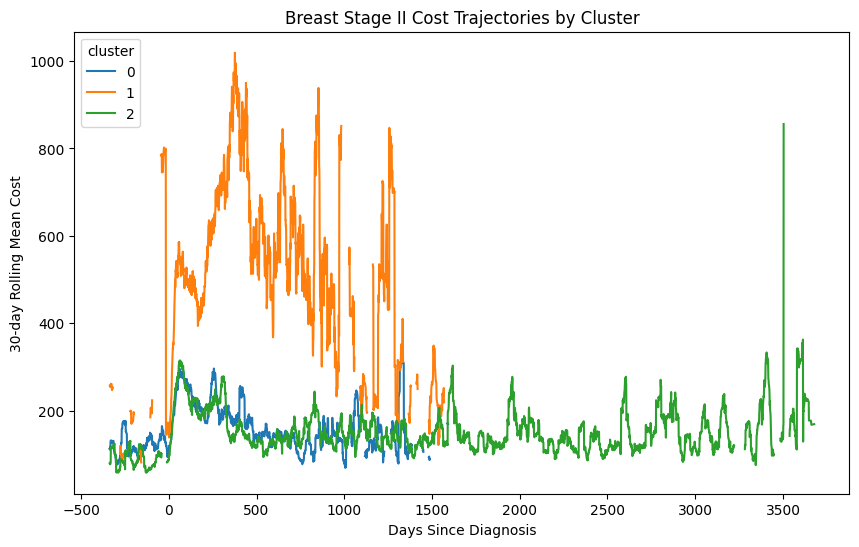

In [109]:
cluster_daily = (
    cohort
    .groupby(['days_since_earliest_dt', 'cluster'])
    .agg(mean_cost=('c_allowed', 'mean'))
    .reset_index()
)

pivot = cluster_daily.pivot(
    index='days_since_earliest_dt',
    columns='cluster',
    values='mean_cost'
)

rolling = pivot.rolling(30).mean()

rolling.plot(figsize=(10,6))
plt.title("Breast Stage II Cost Trajectories by Cluster")
plt.xlabel("Days Since Diagnosis")
plt.ylabel("30-day Rolling Mean Cost")
plt.show()

In [110]:
patient_matrix.groupby('cluster')[
    ['time_to_stage', 'followup', 
     'mean_initial', 'mean_continuing', 
     'mean_late', 'total_cost']
].mean()

,time_to_stage,followup,mean_initial,mean_continuing,mean_late,total_cost
cluster,,,,,,
0,-102.524324,770.513514,193.219446,128.538080,167.983358,95004.575060
1,133.468750,1275.843750,476.611841,662.855065,571.157738,512423.530981
2,540.555556,2841.801587,188.175502,149.074471,156.681559,165455.157903


In [111]:
patient_matrix.groupby('cluster')['time_to_stage'].describe()

,count,mean,std,min,25%,50%,75%,max
cluster,,,,,,,,
0,185.0,-102.524324,708.879697,-2843.0,0.0,28.0,104.00,1625.0
1,64.0,133.468750,349.286391,-6.0,7.0,21.5,60.25,2075.0
2,126.0,540.555556,658.909214,-474.0,59.0,298.0,898.75,3454.0
